# P2 · 00 — From a time series to a supervised table

Project 1 modelled the series *as* a series (ARIMA, ETS). Project 2 takes the other
great approach: **reframe forecasting as supervised regression**. Predict $y_t$ from
a row of features $X_t$ built out of the **past**:

$$\underbrace{[\,y_{t-1},\,y_{t-2},\dots,\ \text{rolling mean/std},\ \text{season},\ \text{trend}\,]}_{X_t}
\;\longrightarrow\; y_t.$$

**Why bother?** It unlocks the entire ML toolbox — gradient boosting, arbitrary
**exogenous** drivers, nonlinear interactions, and training one model across **many
series** at once. **The cost:** *you* must encode time structure as features and,
above all, avoid **leakage** (letting future information into $X_t$).

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))   # repo root
warnings.filterwarnings("ignore")
try:
    from statsmodels.tools.sm_exceptions import (
        ConvergenceWarning, InterpolationWarning, ValueWarning)
    for _w in (ConvergenceWarning, InterpolationWarning, ValueWarning):
        warnings.simplefilter("ignore", _w)
except Exception:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import data, plots
plots.setup()

from src import features as F
q = data.load_quarterly()
logy = np.log(q["gdp_nsa"])          # we engineer features on log GDP
X, y = F.build_supervised(logy, lags=(1, 2, 3, 4), rolls=(4,),
                          fourier_order=2, period=4, trend=True, target="growth")
print("design matrix:", X.shape, "| target:", y.name)
X.head()

design matrix: (84, 11) | target: growth


,lag1,lag2,lag3,lag4,rmean4,rstd4,trend,sin1,cos1,sin2,cos2
2005Q2,16.905360,16.866938,16.752037,16.741376,16.816428,0.071132,4.0,1.000000e+00,6.123234e-17,1.224647e-16,-1.0
2005Q3,16.829606,16.905360,16.866938,16.752037,16.838485,0.056643,5.0,1.224647e-16,-1.000000e+00,-2.449294e-16,1.0
2005Q4,16.833098,16.829606,16.905360,16.866938,16.858750,0.030606,6.0,-1.000000e+00,-1.836970e-16,3.673940e-16,-1.0
2006Q1,16.952871,16.833098,16.829606,16.905360,16.880234,0.051702,7.0,0.000000e+00,1.000000e+00,0.000000e+00,1.0
2006Q2,17.003920,16.952871,16.833098,16.829606,16.904874,0.075715,8.0,1.000000e+00,6.123234e-17,1.224647e-16,-1.0


### The feature families (read a row left to right)

| feature | meaning | why |
|---------|---------|-----|
| `lag1…lag4` | log-GDP 1–4 quarters ago | autoregressive memory; lag4 captures "a year ago" |
| `rmean4`, `rstd4` | rolling mean / std of last 4 | local level & volatility |
| `trend` | row counter (time index) | a linear time position — *but watch §01* |
| `sin1,cos1,sin2,cos2` | Fourier terms of the quarter | smooth seasonality without 4 dummies |

Every value in row $t$ is computed from data **strictly before** $t$
(`features.feature_row` only ever sees `hist[:t]`). That is the anti-leakage
guarantee — and the same function builds these rows *and* each step of a forecast,
so train-time and forecast-time features can never drift apart.

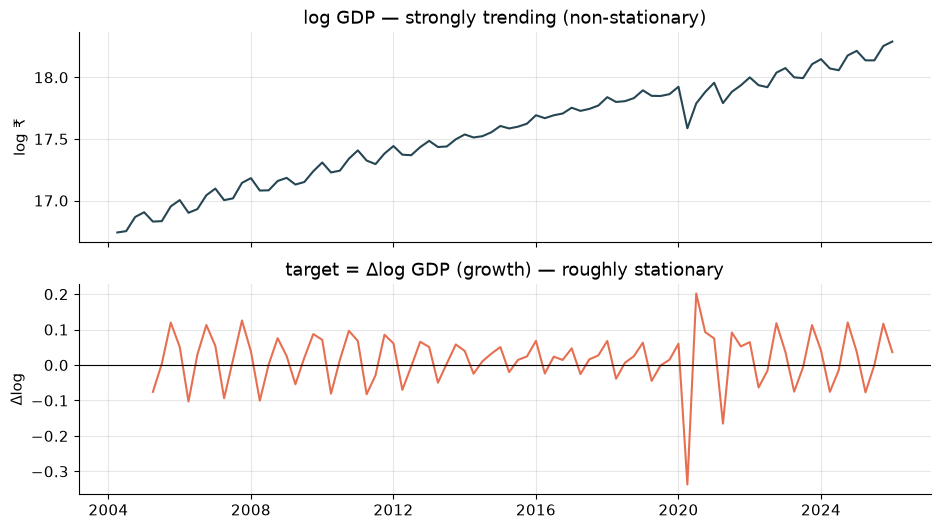

growth target: mean 0.0165  std 0.0752


In [2]:
# The target here is GROWTH (Δlog), not the level — preview of why in §01.
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(logy.index.to_timestamp(how="start"), logy.values, color="#264653")
axes[0].set(title="log GDP — strongly trending (non-stationary)", ylabel="log ₹")
axes[1].plot(y.index.to_timestamp(how="start"), y.values, color="#e76f51")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set(title="target = Δlog GDP (growth) — roughly stationary", ylabel="Δlog")
plt.show()
print("growth target: mean %.4f  std %.4f" % (y.mean(), y.std()))

### Leakage — the cardinal sin

The number-one way ML forecasts lie to you: a feature that "knows" the answer.
Classic mistakes — a rolling mean that includes the current point, a `StandardScaler`
fit on the whole series before splitting, or shuffling rows in cross-validation.

Our defences, baked into the toolkit:
* features for period $t$ use only `hist[:t]` (never $y_t$ itself);
* evaluation is **rolling-origin** (`src/backtest.py`), never a shuffled split;
* the *same* `feature_row` is used to train and to forecast.

---
**Next (01):** the single biggest gotcha when you feed this table to a tree — and
why the target above is *growth*, not *level*.